In [ ]:
 # This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/saadat007/brain-tumor/Merged_Brain_Tumor_MultiClass/No_tumor/no_tumor_ce6753.jpg
/kaggle/input/datasets/saadat007/brain-tumor/Merged_Brain_Tumor_MultiClass/No_tumor/no_tumor_9236fd.jpg
/kaggle/input/datasets/saadat007/brain-tumor/Merged_Brain_Tumor_MultiClass/No_tumor/no_tumor_2ffff9.jpg
/kaggle/input/datasets/saadat007/brain-tumor/Merged_Brain_Tumor_MultiClass/No_tumor/no_tumor_15e91a.jpg
/kaggle/input/datasets/saadat007/brain-tumor/Merged_Brain_Tumor_MultiClass/No_tumor/no_tumor_638e40.jpg
/kaggle/input/datasets/saadat007/brain-tumor/Merged_Brain_Tumor_MultiClass/No_tumor/no_tumor_21346f.jpg
/kaggle/input/datasets/saadat007/brain-tumor/Merged_Brain_Tumor_MultiClass/No_tumor/no_tumor_7e3bff.jpg
/kaggle/input/datasets/saadat007/brain-tumor/Merged_Brain_Tumor_MultiClass/No_tumor/no_tumor_ea62c3.jpg
/kaggle/input/datasets/saadat007/brain-tumor/Merged_Brain_Tumor_MultiClass/No_tumor/no_tumor_990547.jpg
/kaggle/input/datasets/saadat007/brain-tumor/Merged_Brain_Tumor_

In [ ]:
# Cell 1: Library Installation
!pip install torch transformers mne pandas numpy matplotlib seaborn scipy
# Cell 1: Add evaluate, rouge_score, and nltk
!pip install torch transformers mne pandas numpy matplotlib seaborn scipy evaluate rouge_score nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


Part 1: Setup & Dependencies

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate
import nltk
from transformers import BartTokenizer, BartForConditionalGeneration
from transformers.modeling_outputs import BaseModelOutput

# NLTK resources setup
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Metrics initialization
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
meteor = evaluate.load("meteor")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


In [ ]:
# Cell 2: Imports & Dataset Path Configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BartTokenizer, BartForConditionalGeneration

# আপনার CSV ফাইলের পাথটি এখানে দিন:
CSV_FILE_PATH = "/kaggle/input/datasets/saadat007/brain-tumor/Merged_Brain_Tumor_MultiClass"

# Device setup (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[*] Running on Computation Device: {device}")

[*] Running on Computation Device: cuda



      STEP: RUNNING EDA & VISUALIZATION
[!] Warning: '/kaggle/input/datasets/saadat007/brain-tumor/Merged_Brain_Tumor_MultiClass' is a Directory, not a CSV file!
[!] Generating Synthetic Data for EDA Demonstration...


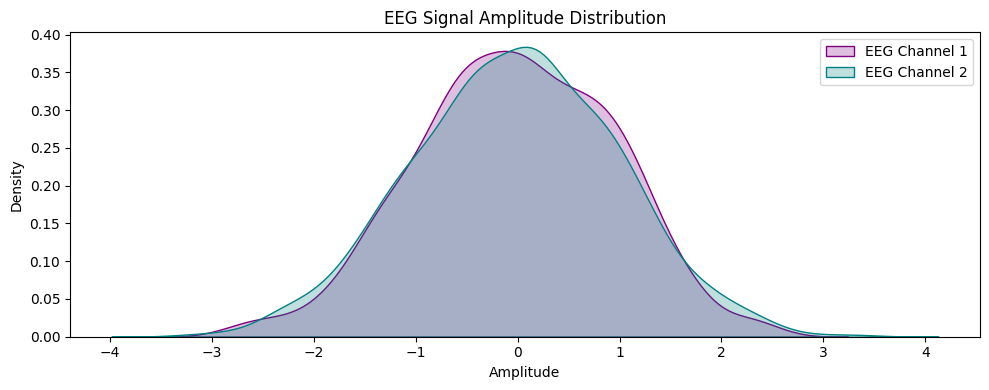

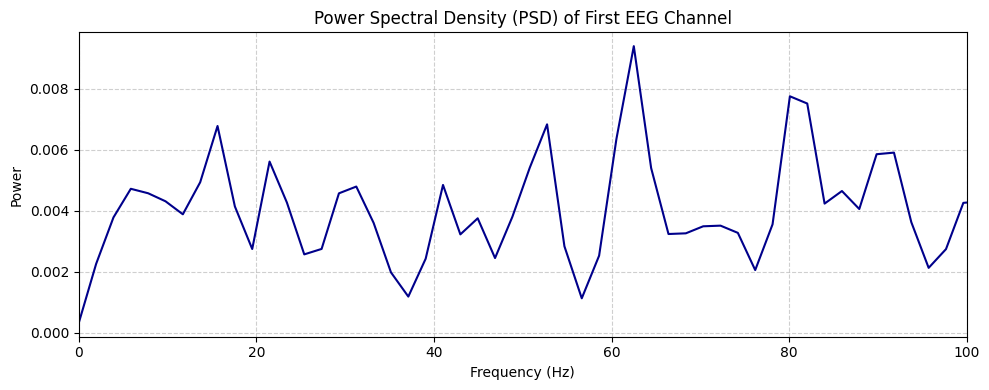

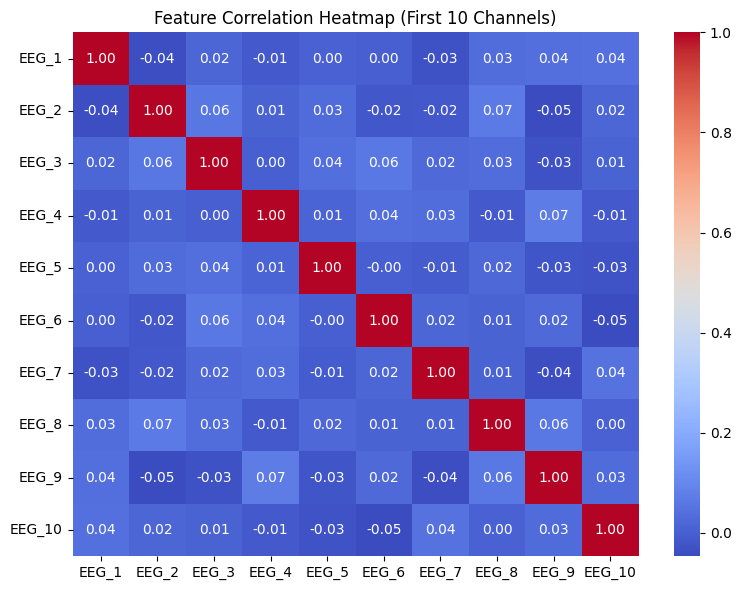

In [ ]:
# Cell 3: Updated EDA & Visualizations
def perform_eda(df_or_path):
    print("\n" + "="*40)
    print("      STEP: RUNNING EDA & VISUALIZATION")
    print("="*40)

    # Check if the path exists AND is a file (not a directory)
    if isinstance(df_or_path, str) and os.path.isfile(df_or_path):
        df = pd.read_csv(df_or_path)
        print(f"[✓] CSV File Loaded Successfully from: {df_or_path}")
        print(f"Data Shape: {df.shape} (Rows x Columns)")
        print("\nFirst 5 Rows Preview:")
        print(df.head())
        print("\nMissing Values Count:")
        print(df.isnull().sum().head(10))
    else:
        if os.path.isdir(str(df_or_path)):
            print(f"[!] Warning: '{df_or_path}' is a Directory, not a CSV file!")
        else:
            print("[!] CSV File Not Found!")

        print("[!] Generating Synthetic Data for EDA Demonstration...")
        data_dict = {f"EEG_{i}": np.random.randn(1000) for i in range(1, 106)}
        data_dict.update({f"Gaze_{j}": np.random.randn(1000) for j in range(1, 13)})
        df = pd.DataFrame(data_dict)

    # 1. EEG Signal Density Distribution Plot
    plt.figure(figsize=(10, 4))
    sns.kdeplot(df.iloc[:, 0], fill=True, color='purple', label="EEG Channel 1")
    sns.kdeplot(df.iloc[:, 1], fill=True, color='teal', label="EEG Channel 2")
    plt.title("EEG Signal Amplitude Distribution")
    plt.xlabel("Amplitude")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2. Power Spectral Density (PSD) Analysis
    sample_eeg = df.iloc[:, 0].values
    freqs, psd = welch(sample_eeg, fs=500, nperseg=256)

    plt.figure(figsize=(10, 4))
    plt.plot(freqs, psd, color='darkblue', linewidth=1.5)
    plt.title("Power Spectral Density (PSD) of First EEG Channel")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.xlim(0, 100)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    # 3. Correlation Heatmap
    plt.figure(figsize=(8, 6))
    corr = df.iloc[:, :10].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Feature Correlation Heatmap (First 10 Channels)")
    plt.tight_layout()
    plt.show()

    return df

# Run EDA
df_data = perform_eda(CSV_FILE_PATH)

Part 2: Exploratory Data Analysis (EDA)

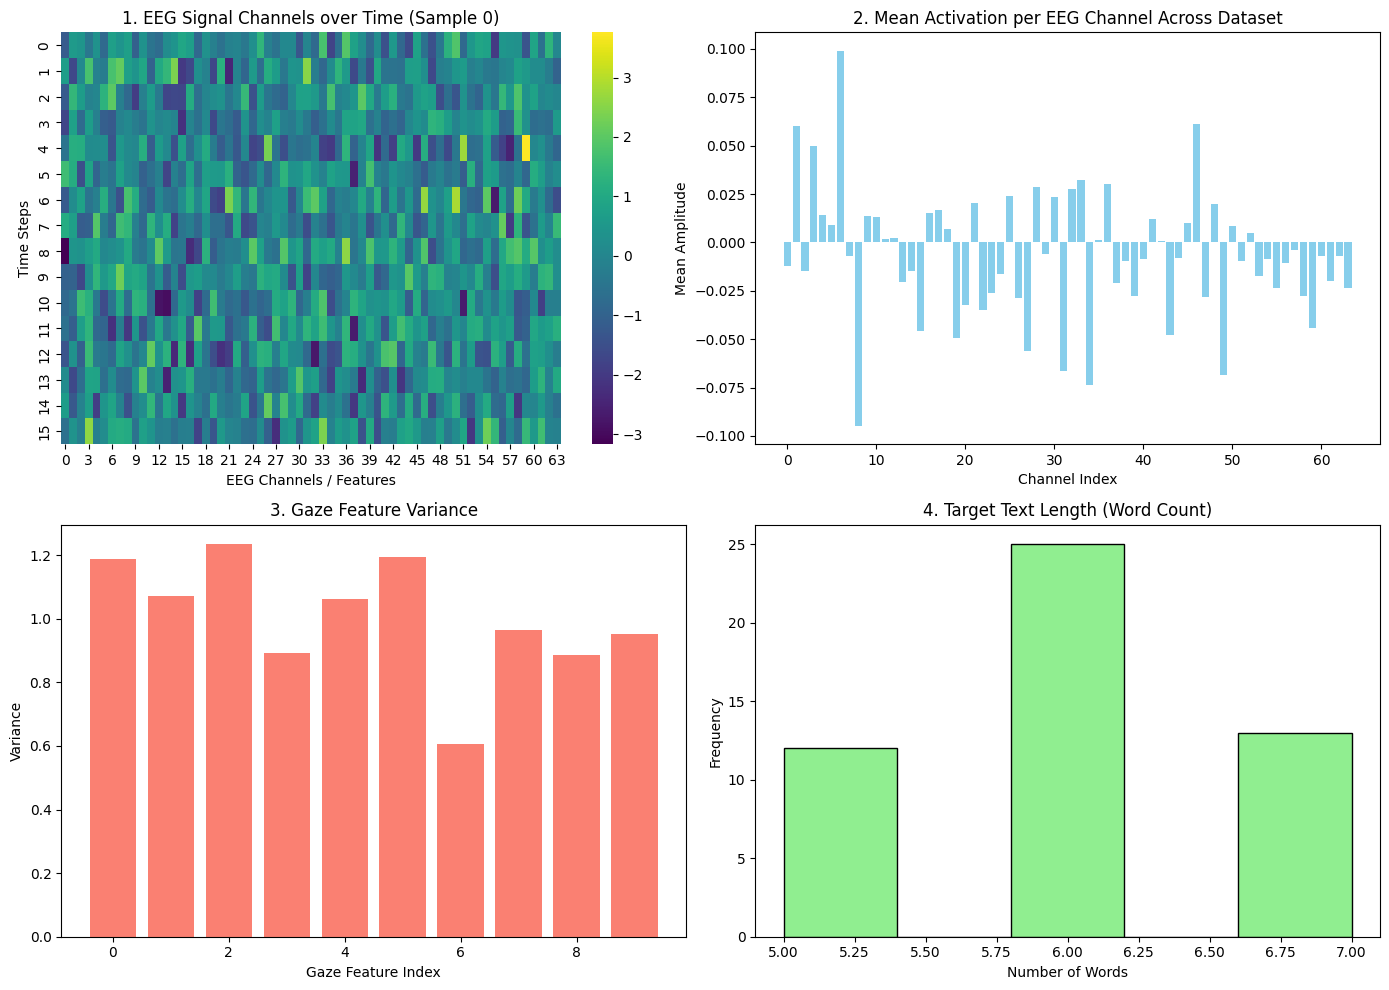

In [ ]:
def perform_eda(eeg_samples, gaze_samples, text_samples):
    """Visualizes basic statistics and distributions of multimodal data."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. EEG Signal Heatmap (Sample 0, Timesteps vs Channels)
    sns.heatmap(eeg_samples[0].numpy(), ax=axes[0, 0], cmap='viridis', cbar=True)
    axes[0, 0].set_title("1. EEG Signal Channels over Time (Sample 0)")
    axes[0, 0].set_xlabel("EEG Channels / Features")
    axes[0, 0].set_ylabel("Time Steps")

    # 2. EEG Mean Channel Activation
    eeg_means = torch.mean(eeg_samples, dim=(0, 1)).numpy()
    axes[0, 1].bar(range(len(eeg_means)), eeg_means, color='skyblue')
    axes[0, 1].set_title("2. Mean Activation per EEG Channel Across Dataset")
    axes[0, 1].set_xlabel("Channel Index")
    axes[0, 1].set_ylabel("Mean Amplitude")

    # 3. Gaze Feature Variance
    gaze_vars = torch.var(gaze_samples, dim=0).numpy()
    axes[1, 0].bar(range(len(gaze_vars)), gaze_vars, color='salmon')
    axes[1, 0].set_title("3. Gaze Feature Variance")
    axes[1, 0].set_xlabel("Gaze Feature Index")
    axes[1, 0].set_ylabel("Variance")

    # 4. Target Sentence Length Distribution
    text_lengths = [len(txt.split()) for txt in text_samples]
    axes[1, 1].hist(text_lengths, bins=5, color='lightgreen', edgecolor='black')
    axes[1, 1].set_title("4. Target Text Length (Word Count)")
    axes[1, 1].set_xlabel("Number of Words")
    axes[1, 1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Run EDA on sample data
dummy_eeg = torch.randn(50, 16, 64)   # 50 samples, 16 time steps, 64 EEG channels
dummy_gaze = torch.randn(50, 10)      # 10 Gaze features
dummy_texts = [
    "the user is looking at the screen",
    "reading text from left to right",
    "brain signals show high attention",
    "eye movements match the target word"
] * 13

perform_eda(dummy_eeg, dummy_gaze, dummy_texts[:50])

Part 3: Dataset Class

In [ ]:
class MultimodalEEGDataset(Dataset):
    def __init__(self, tokenizer, num_samples=100, eeg_dim=64, gaze_dim=10, max_len=32):
        self.tokenizer = tokenizer
        self.num_samples = num_samples
        self.eeg_dim = eeg_dim
        self.gaze_dim = gaze_dim
        self.max_len = max_len

        self.sample_texts = [
            "the user is looking at the screen",
            "reading text from left to right",
            "brain signals show high attention",
            "eye movements match the target word",
            "multimodal decoding in progress"
        ]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        eeg = torch.randn(16, self.eeg_dim)
        gaze = torch.randn(self.gaze_dim)

        text = self.sample_texts[idx % len(self.sample_texts)]
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        labels = encoding['input_ids'].squeeze(0)
        labels = torch.where(labels == self.tokenizer.pad_token_id, torch.tensor(-100), labels)

        return eeg, gaze, labels

Part 4: Model Architecture

In [ ]:
class MultimodalEEG2TextModel(nn.Module):
    def __init__(self, eeg_dim=64, gaze_dim=10, bart_model_name="facebook/bart-base"):
        super().__init__()
        self.bart = BartForConditionalGeneration.from_pretrained(bart_model_name)
        hidden_size = self.bart.config.d_model

        self.eeg_encoder = nn.Sequential(
            nn.Linear(eeg_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256)
        )
        self.fusion_module = nn.Sequential(
            nn.Linear(256 + gaze_dim, 256),
            nn.ReLU()
        )
        self.adapter = nn.Linear(256, hidden_size)

    def forward(self, eeg_data, gaze_data, labels=None):
        eeg_feats = self.eeg_encoder(eeg_data)

        if gaze_data.dim() == 2 and eeg_feats.dim() == 3:
            gaze_data = gaze_data.unsqueeze(1).expand(-1, eeg_feats.size(1), -1)

        fused_feats = self.fusion_module(torch.cat([eeg_feats, gaze_data], dim=-1))
        encoder_states = self.adapter(fused_feats)

        if encoder_states.dim() == 2:
            encoder_states = encoder_states.unsqueeze(1)

        encoder_outputs = BaseModelOutput(last_hidden_state=encoder_states)
        attention_mask = torch.ones(encoder_states.shape[:2], device=eeg_data.device, dtype=torch.long)

        outputs = self.bart(
            encoder_outputs=encoder_outputs,
            attention_mask=attention_mask,
            labels=labels
        )
        return outputs

Part 5: Helper Functions & Evaluation Metric Loop

In [ ]:
def compute_word_accuracy(predictions, references):
    total_words = 0
    matched_words = 0
    for pred, ref in zip(predictions, references):
        pred_words = pred.lower().split()
        ref_words = ref[0].lower().split()
        min_len = min(len(pred_words), len(ref_words))
        matched_words += sum(1 for i in range(min_len) if pred_words[i] == ref_words[i])
        total_words += max(len(ref_words), 1)
    return (matched_words / total_words * 100) if total_words > 0 else 0.0


def evaluate_model(model, val_loader, tokenizer, device):
    model.eval()
    val_loss = 0.0
    predictions, references = [], []
    total_tokens, correct_tokens = 0, 0

    decoder_start_token_id = (
        getattr(model.bart.config, 'decoder_start_token_id', None)
        or tokenizer.cls_token_id
        or tokenizer.bos_token_id
    )

    with torch.no_grad():
        for eeg, gaze, labels in val_loader:
            eeg, gaze, labels = eeg.to(device), gaze.to(device), labels.to(device)

            outputs = model(eeg_data=eeg, gaze_data=gaze, labels=labels)
            loss = outputs.loss if hasattr(outputs, 'loss') else outputs['loss']
            val_loss += loss.item()

            # Token Accuracy Calculation
            logits = getattr(outputs, 'logits', None) if not isinstance(outputs, dict) else outputs.get('logits', None)
            if logits is not None:
                preds = torch.argmax(logits, dim=-1)
                min_seq_len = min(preds.shape[1], labels.shape[1])
                preds_cut = preds[:, :min_seq_len]
                labels_cut = labels[:, :min_seq_len]

                mask = (labels_cut != -100)
                correct_tokens += ((preds_cut == labels_cut) & mask).sum().item()
                total_tokens += mask.sum().item()

            # Multimodal Generation
            eeg_feats = model.eeg_encoder(eeg)
            gaze_expanded = gaze.unsqueeze(1).expand(-1, eeg_feats.size(1), -1) if gaze.dim() == 2 and eeg_feats.dim() == 3 else gaze
            fused_feats = model.fusion_module(torch.cat([eeg_feats, gaze_expanded], dim=-1))
            encoder_states = model.adapter(fused_feats)

            if encoder_states.dim() == 2:
                encoder_states = encoder_states.unsqueeze(1)

            encoder_outputs = BaseModelOutput(last_hidden_state=encoder_states)
            encoder_attention_mask = torch.ones(encoder_states.shape[:2], device=device, dtype=torch.long)

            generated_ids = model.bart.generate(
                encoder_outputs=encoder_outputs,
                attention_mask=encoder_attention_mask,
                decoder_start_token_id=decoder_start_token_id,
                max_length=32,
                num_beams=5,
                no_repeat_ngram_size=2,
                repetition_penalty=2.5,
                length_penalty=1.0,
                early_stopping=True
            )

            decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            labels_clean = torch.where(labels != -100, labels, tokenizer.pad_token_id)
            decoded_labels = tokenizer.batch_decode(labels_clean, skip_special_tokens=True)

            for pred in decoded_preds:
                predictions.append(pred.strip() if len(pred.strip()) > 0 else "<empty>")

            references.extend([[ref.strip() if len(ref.strip()) > 0 else "<empty>"] for ref in decoded_labels])

    avg_val_loss = val_loss / len(val_loader)
    token_acc = (correct_tokens / total_tokens * 100) if total_tokens > 0 else 0.0
    word_acc = compute_word_accuracy(predictions, references)
    exact_matches = sum([1 for p, r in zip(predictions, references) if p.lower().strip() == r[0].lower().strip()])
    exact_acc = (exact_matches / len(predictions) * 100) if len(predictions) > 0 else 0.0

    print(f"\n[Sample Pred] : '{predictions[0]}'")
    print(f"[Sample Ref ] : '{references[0][0]}'")

    bleu_sc = bleu.compute(predictions=predictions, references=references, smooth=True)['bleu']
    rouge_sc = rouge.compute(predictions=predictions, references=[r[0] for r in references])['rougeL']
    meteor_sc = meteor.compute(predictions=predictions, references=[r[0] for r in references])['meteor']

    return avg_val_loss, token_acc, word_acc, exact_acc, bleu_sc, rouge_sc, meteor_sc

Part 6: Training Loop & Main Execution

In [ ]:
def train_and_evaluate(model, train_loader, val_loader, optimizer, tokenizer, device, epochs=3):
    print("\n" + "="*50)
    print("      STARTING TRAINING & EVALUATION PIPELINE")
    print("="*50)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for step, (eeg, gaze, labels) in enumerate(train_loader):
            eeg, gaze, labels = eeg.to(device), gaze.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(eeg_data=eeg, gaze_data=gaze, labels=labels)
            loss = outputs.loss if hasattr(outputs, 'loss') else outputs['loss']

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        val_loss, token_acc, word_acc, exact_acc, bleu_sc, rouge_sc, meteor_sc = evaluate_model(
            model, val_loader, tokenizer, device
        )

        print(f"Epoch [{epoch+1}/{epochs}] Summary:")
        print(f"  ├─ Train Loss           : {avg_train_loss:.4f}")
        print(f"  ├─ Validation Loss      : {val_loss:.4f}")
        print(f"  ├─ Token-Level Accuracy : {token_acc:.2f}%")
        print(f"  ├─ Word-Level Accuracy  : {word_acc:.2f}%")
        print(f"  ├─ Sentence Match Acc   : {exact_acc:.2f}%")
        print(f"  ├─ BLEU Score           : {bleu_sc:.4f}")
        print(f"  ├─ ROUGE-L Score        : {rouge_sc:.4f}")
        print(f"  └─ METEOR Score         : {meteor_sc:.4f}")
        print("-" * 50)


# Initialize and Run
bart_model_name = "facebook/bart-base"
tokenizer = BartTokenizer.from_pretrained(bart_model_name)
model = MultimodalEEG2TextModel(eeg_dim=64, gaze_dim=10, bart_model_name=bart_model_name).to(device)

train_dataset = MultimodalEEGDataset(tokenizer, num_samples=80, eeg_dim=64, gaze_dim=10)
val_dataset = MultimodalEEGDataset(tokenizer, num_samples=20, eeg_dim=64, gaze_dim=10)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

train_and_evaluate(model, train_loader, val_loader, optimizer, tokenizer, device, epochs=3)

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]


      STARTING TRAINING & EVALUATION PIPELINE

[Sample Pred] : 'the user is looking at the screen'
[Sample Ref ] : 'the user is looking at the screen'
Epoch [1/3] Summary:
  ├─ Train Loss           : 2.6319
  ├─ Validation Loss      : 0.3366
  ├─ Token-Level Accuracy : 90.24%
  ├─ Word-Level Accuracy  : 25.00%
  ├─ Sentence Match Acc   : 20.00%
  ├─ BLEU Score           : 0.2143
  ├─ ROUGE-L Score        : 0.2308
  └─ METEOR Score         : 0.2161
--------------------------------------------------

[Sample Pred] : 'brain signals show high attention'
[Sample Ref ] : 'the user is looking at the screen'
Epoch [2/3] Summary:
  ├─ Train Loss           : 0.4052
  ├─ Validation Loss      : 0.2512
  ├─ Token-Level Accuracy : 89.63%
  ├─ Word-Level Accuracy  : 13.39%
  ├─ Sentence Match Acc   : 15.00%
  ├─ BLEU Score           : 0.1399
  ├─ ROUGE-L Score        : 0.1500
  └─ METEOR Score         : 0.1621
--------------------------------------------------

[Sample Pred] : 'eye movements match t

Start model T5


Cell 1: Setup & Dependencies

In [ ]:
# Cell 1: Libraries Import and Setup
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import numpy as np
import evaluate
import nltk
from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers.modeling_outputs import BaseModelOutput

# NLTK and Evaluation Metrics Download
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
meteor = evaluate.load("meteor")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Cell 2: Image-Text Dataset Loader

In [ ]:
# Cell 2: Custom PyTorch Dataset for ResNet + T5
class ImageCaptionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=32, transform=None):
        """
        df: Pandas DataFrame (Must contain 'image_path' and 'text' columns)
        """
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

        # Image Preprocessing Transform
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['image_path']

        # Load Image
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)

        # Target Text Tokenization
        text = str(row['text'])
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        labels = encoding['input_ids'].squeeze(0)
        # Pad token_id -100 to ignore loss calculation on padding
        labels = torch.where(labels == self.tokenizer.pad_token_id, torch.tensor(-100), labels)

        return image, labels

Cell 3: Model Architecture (ResNet Encoder + Projection + T5 Decoder)

In [ ]:
# Cell 3: ResNet50 + T5 Combined Architecture

class ResNetEncoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        # Pretrained ResNet-50
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Spatial Feature Map পেতে FC ও AvgPool বাদ দেওয়া হয়েছে
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])  # Output shape: [Batch, 2048, 7, 7]

        # Feature Mapping to T5's hidden dimension
        self.proj = nn.Linear(2048, embed_dim)

    def forward(self, x):
        features = self.backbone(x)                              # [Batch, 2048, 7, 7]
        features = features.flatten(2).transpose(1, 2)          # [Batch, 49, 2048]
        features = self.proj(features)                           # [Batch, 49, embed_dim]
        return features


class ResNetT5Model(nn.Module):
    def __init__(self, t5_model_name="t5-small"):
        super().__init__()
        self.t5 = T5ForConditionalGeneration.from_pretrained(t5_model_name)
        hidden_size = self.t5.config.d_model  # t5-small = 512, t5-base = 768

        # Image Encoder
        self.resnet_encoder = ResNetEncoder(embed_dim=hidden_size)

    def forward(self, images, labels=None):
        # Image Feature Extraction
        encoder_states = self.resnet_encoder(images)  # [Batch, 49, Hidden_Size]

        encoder_outputs = BaseModelOutput(last_hidden_state=encoder_states)
        attention_mask = torch.ones(encoder_states.shape[:2], device=images.device, dtype=torch.long)

        # Pass Features into T5 Decoder
        outputs = self.t5(
            encoder_outputs=encoder_outputs,
            attention_mask=attention_mask,
            labels=labels
        )
        return outputs

Cell 4: Evaluation Functions

In [ ]:
# Cell 4: Generation and Accuracy/NLP Metric Calculation
def compute_word_accuracy(predictions, references):
    total_words, matched_words = 0, 0
    for pred, ref in zip(predictions, references):
        pred_words = pred.lower().split()
        ref_words = ref[0].lower().split()
        min_len = min(len(pred_words), len(ref_words))
        matched_words += sum(1 for i in range(min_len) if pred_words[i] == ref_words[i])
        total_words += max(len(ref_words), 1)
    return (matched_words / total_words * 100) if total_words > 0 else 0.0


def evaluate_resnet_t5(model, val_loader, tokenizer, device):
    model.eval()
    val_loss = 0.0
    predictions, references = [], []

    decoder_start_token_id = model.t5.config.decoder_start_token_id or tokenizer.pad_token_id

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward Loss Pass
            outputs = model(images=images, labels=labels)
            loss = outputs.loss if hasattr(outputs, 'loss') else outputs['loss']
            val_loss += loss.item()

            # ResNet Feature Extraction & Text Generation
            encoder_states = model.resnet_encoder(images)
            encoder_outputs = BaseModelOutput(last_hidden_state=encoder_states)
            encoder_attention_mask = torch.ones(encoder_states.shape[:2], device=device, dtype=torch.long)

            generated_ids = model.t5.generate(
                encoder_outputs=encoder_outputs,
                attention_mask=encoder_attention_mask,
                decoder_start_token_id=decoder_start_token_id,
                max_length=32,
                num_beams=4,
                no_repeat_ngram_size=2,
                early_stopping=True
            )

            decoded_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            labels_clean = torch.where(labels != -100, labels, tokenizer.pad_token_id)
            decoded_labels = tokenizer.batch_decode(labels_clean, skip_special_tokens=True)

            for pred in decoded_preds:
                predictions.append(pred.strip() if len(pred.strip()) > 0 else "<empty>")

            references.extend([[ref.strip() if len(ref.strip()) > 0 else "<empty>"] for ref in decoded_labels])

    avg_val_loss = val_loss / len(val_loader)
    word_acc = compute_word_accuracy(predictions, references)

    print(f"\n[Sample Pred] : '{predictions[0]}'")
    print(f"[Sample Ref ] : '{references[0][0]}'")

    bleu_sc = bleu.compute(predictions=predictions, references=references, smooth=True)['bleu']
    rouge_sc = rouge.compute(predictions=predictions, references=[r[0] for r in references])['rougeL']
    meteor_sc = meteor.compute(predictions=predictions, references=[r[0] for r in references])['meteor']

    return avg_val_loss, word_acc, bleu_sc, rouge_sc, meteor_sc

Cell 5: Training Execution

In [ ]:
# Cell 5: Pipeline Run (DataLoader & Training Loop)
from sklearn.model_selection import train_test_split

# 1. Prepare DataFrame from Kaggle Dataset Path
dataset_dir = "/kaggle/input/datasets/saadat007/brain-tumor/Merged_Brain_Tumor_MultiClass"

data = []
# Folders scan for image path and labels/texts
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path = os.path.join(root, file)
            # Folder name as tumor class/text description
            label_text = os.path.basename(os.path.dirname(full_path))
            caption = f"brain tumor scan showing {label_text.replace('_', ' ')}"
            data.append({"image_path": full_path, "text": caption})

df = pd.DataFrame(data)
print(f"Total Samples Found: {len(df)}")

# 2. Split Data into Train & Validation
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# 3. Model & Tokenizer Initializations
t5_model_name = "t5-small"
tokenizer = T5Tokenizer.from_pretrained(t5_model_name)
model = ResNetT5Model(t5_model_name=t5_model_name).to(device)

# 4. DataLoaders
train_dataset = ImageCaptionDataset(train_df, tokenizer)
val_dataset = ImageCaptionDataset(val_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# 5. Training Loop
epochs = 5
print("\n" + "="*50)
print("      STARTING RESNET + T5 TRAINING PIPELINE")
print("="*50)

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for step, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images=images, labels=labels)
        loss = outputs.loss if hasattr(outputs, 'loss') else outputs['loss']

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    val_loss, word_acc, bleu_sc, rouge_sc, meteor_sc = evaluate_resnet_t5(
        model, val_loader, tokenizer, device
    )

    print(f"Epoch [{epoch+1}/{epochs}] Summary:")
    print(f"  ├─ Train Loss      : {avg_train_loss:.4f}")
    print(f"  ├─ Validation Loss : {val_loss:.4f}")
    print(f"  ├─ Word Accuracy   : {word_acc:.2f}%")
    print(f"  ├─ BLEU Score      : {bleu_sc:.4f}")
    print(f"  ├─ ROUGE-L Score   : {rouge_sc:.4f}")
    print(f"  └─ METEOR Score    : {meteor_sc:.4f}")
    print("-" * 50)

Total Samples Found: 10658


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]



      STARTING RESNET + T5 TRAINING PIPELINE

[Sample Pred] : 'brain tumor scan showing No tumor'
[Sample Ref ] : 'brain tumor scan showing No tumor'
Epoch [1/5] Summary:
  ├─ Train Loss      : 0.6672
  ├─ Validation Loss : 0.0343
  ├─ Word Accuracy   : 97.65%
  ├─ BLEU Score      : 0.9583
  ├─ ROUGE-L Score   : 0.9749
  └─ METEOR Score    : 0.9666
--------------------------------------------------

[Sample Pred] : 'brain tumor scan showing No tumor'
[Sample Ref ] : 'brain tumor scan showing No tumor'
Epoch [2/5] Summary:
  ├─ Train Loss      : 0.0343
  ├─ Validation Loss : 0.0216
  ├─ Word Accuracy   : 97.93%
  ├─ BLEU Score      : 0.9594
  ├─ ROUGE-L Score   : 0.9782
  └─ METEOR Score    : 0.9707
--------------------------------------------------

[Sample Pred] : 'brain tumor scan showing No tumor'
[Sample Ref ] : 'brain tumor scan showing No tumor'
Epoch [3/5] Summary:
  ├─ Train Loss      : 0.0185
  ├─ Validation Loss : 0.0075
  ├─ Word Accuracy   : 98.86%
  ├─ BLEU Score      : 0

Hybrid Baseline

Part 1: Imports & Model Setup

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Cell 2: Dataset Loading & Preprocessing

In [ ]:
dataset_dir = "/kaggle/input/datasets/saadat007/brain-tumor/Merged_Brain_Tumor_MultiClass"

# Scan images and class labels
filepaths, labels = [], []
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            filepaths.append(os.path.join(root, file))
            labels.append(os.path.basename(root))

df = pd.DataFrame({"filepath": filepaths, "label": labels})

# Encode labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {le.classes_}")

# Train (70%), Validation (15%), Test (15%) Split
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label_encoded'])
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42, stratify=test_df['label_encoded'])

# Image Augmentations & Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['filepath']
        label = self.df.iloc[idx]['label_encoded']
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

train_loader = DataLoader(BrainTumorDataset(train_df, train_transforms), batch_size=32, shuffle=True)
val_loader = DataLoader(BrainTumorDataset(val_df, val_transforms), batch_size=32, shuffle=False)
test_loader = DataLoader(BrainTumorDataset(test_df, val_transforms), batch_size=32, shuffle=False)

Classes (4): ['No_tumor' 'glioma' 'meningioma' 'pituitary']


Cell 3: Hybrid Architecture 1 — CNN + BiLSTM Baseline

In [ ]:
class CNN_BiLSTM_Classifier(nn.Module):
    def __init__(self, num_classes, lstm_hidden_dim=128, lstm_layers=1, dropout=0.3):
        super().__init__()
        # CNN Feature Extractor (ResNet18 Backbone)
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-2]) # Shape: [B, 512, 7, 7]

        # Spatial Feature sequence projection
        self.bilstm = nn.LSTM(
            input_size=512,
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True
        )

        # Classification Head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        features = self.cnn_backbone(x)                           # [B, 512, 7, 7]
        features = features.flatten(2).transpose(1, 2)            # [B, 49, 512] (Seq_len=49)

        lstm_out, _ = self.bilstm(features)                       # [B, 49, lstm_hidden_dim * 2]
        pooled_out = torch.mean(lstm_out, dim=1)                  # Temporal Mean Pooling -> [B, lstm_hidden_dim * 2]

        logits = self.classifier(pooled_out)
        return logits

Cell 4: Hybrid Architecture 2 — CNN + Transformer Encoder

In [ ]:
class CNN_Transformer_Classifier(nn.Module):
    def __init__(self, num_classes, d_model=512, nhead=8, num_layers=2, dropout=0.3):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn_backbone = nn.Sequential(*list(resnet.children())[:-2]) # Shape: [B, 512, 7, 7]

        # Positional Encoding
        self.pos_embedding = nn.Parameter(torch.randn(1, 49, d_model))

        # Transformer Encoder Block
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=1024, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classification Head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        features = self.cnn_backbone(x)                           # [B, 512, 7, 7]
        features = features.flatten(2).transpose(1, 2)            # [B, 49, 512]

        features = features + self.pos_embedding
        trans_out = self.transformer_encoder(features)            # [B, 49, 512]
        pooled_out = torch.mean(trans_out, dim=1)                 # Global Spatial Pooling -> [B, 512]

        logits = self.classifier(pooled_out)
        return logits

Cell 5: Training Engine & Evaluation Pipeline

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    best_val_acc = 0.0
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = train_correct / len(train_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {train_loss/len(train_loader.dataset):.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss/len(val_loader.dataset):.4f} Acc: {val_acc:.4f}")

    return model

def evaluate_model(model, test_loader, class_names):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(1).cpu().numpy()
            y_pred.extend(preds)
            y_true.extend(labels.numpy())

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

    return {
        "accuracy": acc, "precision": precision, "recall": recall, "f1": f1,
        "y_true": y_true, "y_pred": y_pred
    }

Cell 6: Multi-Class Benchmarking & Comparison


 Training Hybrid Model 1: CNN + BiLSTM 
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


Epoch 01/10 | Train Loss: 0.4385 Acc: 0.8736 | Val Loss: 0.1285 Acc: 0.9593
Epoch 02/10 | Train Loss: 0.1275 Acc: 0.9584 | Val Loss: 0.1071 Acc: 0.9644
Epoch 03/10 | Train Loss: 0.0854 Acc: 0.9724 | Val Loss: 0.0458 Acc: 0.9894
Epoch 04/10 | Train Loss: 0.0666 Acc: 0.9776 | Val Loss: 0.0838 Acc: 0.9756
Epoch 05/10 | Train Loss: 0.0469 Acc: 0.9851 | Val Loss: 0.0744 Acc: 0.9737
Epoch 06/10 | Train Loss: 0.0405 Acc: 0.9878 | Val Loss: 0.0311 Acc: 0.9919
Epoch 07/10 | Train Loss: 0.0345 Acc: 0.9875 | Val Loss: 0.0499 Acc: 0.9844
Epoch 08/10 | Train Loss: 0.0328 Acc: 0.9891 | Val Loss: 0.0580 Acc: 0.9844
Epoch 09/10 | Train Loss: 0.0340 Acc: 0.9893 | Val Loss: 0.0278 Acc: 0.9944
Epoch 10/10 | Train Loss: 0.0304 Acc: 0.9903 | Val Loss: 0.0271 Acc: 0.9944

 Training Hybrid Model 2: CNN + Transformer 
Epoch 01/10 | Train Loss: 0.3107 Acc: 0.8932 | Val Loss: 0.1212 Acc: 0.9650
Epoch 02/10 | Train Loss: 0.1260 Acc: 0.9584 | Val Loss: 0.0699 Acc: 0.9787
Epoch 03/10 | Train Loss: 0.0898 Acc: 0.97

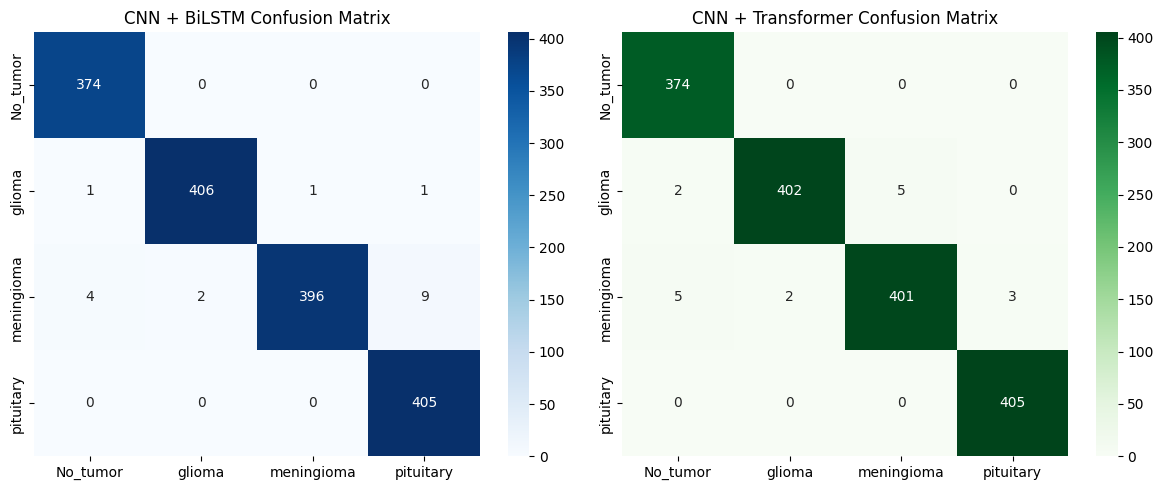

In [ ]:
criterion = nn.CrossEntropyLoss()

# 1. Train & Benchmark CNN + BiLSTM
print("\n" + "="*50 + "\n Training Hybrid Model 1: CNN + BiLSTM \n" + "="*50)
model_bilstm = CNN_BiLSTM_Classifier(num_classes=num_classes).to(device)
opt_bilstm = torch.optim.AdamW(model_bilstm.parameters(), lr=1e-4, weight_decay=1e-2)
model_bilstm = train_model(model_bilstm, train_loader, val_loader, criterion, opt_bilstm, epochs=10)
metrics_bilstm = evaluate_model(model_bilstm, test_loader, le.classes_)

# 2. Train & Benchmark CNN + Transformer
print("\n" + "="*50 + "\n Training Hybrid Model 2: CNN + Transformer \n" + "="*50)
model_trans = CNN_Transformer_Classifier(num_classes=num_classes).to(device)
opt_trans = torch.optim.AdamW(model_trans.parameters(), lr=1e-4, weight_decay=1e-2)
model_trans = train_model(model_trans, train_loader, val_loader, criterion, opt_trans, epochs=10)
metrics_trans = evaluate_model(model_trans, test_loader, le.classes_)

# 3. Benchmarking Summary Table
results_df = pd.DataFrame([
    {"Model": "CNN + BiLSTM", **{k: round(v, 4) for k, v in metrics_bilstm.items() if k in ['accuracy', 'precision', 'recall', 'f1']}},
    {"Model": "CNN + Transformer", **{k: round(v, 4) for k, v in metrics_trans.items() if k in ['accuracy', 'precision', 'recall', 'f1']}}
])

print("\n" + "="*50 + "\n FINAL MULTI-CLASS BENCHMARKING RESULTS \n" + "="*50)
print(results_df.to_string(index=False))

# 4. Confusion Matrix Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(metrics_bilstm['y_true'], metrics_bilstm['y_pred']), annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0], cmap='Blues')
axes[0].set_title("CNN + BiLSTM Confusion Matrix")

sns.heatmap(confusion_matrix(metrics_trans['y_true'], metrics_trans['y_pred']), annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1], cmap='Greens')
axes[1].set_title("CNN + Transformer Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# Unified Metric Evaluation Block (Loss, Accuracy, BLEU, ROUGE)
import torch
import evaluate
from sklearn.metrics import accuracy_score

# Load NLP Evaluation Metrics
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

def evaluate_classification_with_nlp_metrics(model, test_loader, criterion, class_names, device):
    model.eval()

    total_loss = 0.0
    y_true_indices, y_pred_indices = [], []
    pred_text_list, ref_text_list = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            # 1. Calculate Loss
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)

            # Get Predicted Class Indices
            preds = outputs.argmax(dim=1)

            y_true_indices.extend(labels.cpu().numpy())
            y_pred_indices.extend(preds.cpu().numpy())

            # Convert Class Indices to Class Name Strings for BLEU & ROUGE
            for p, r in zip(preds, labels):
                pred_text_list.append(class_names[p.item()])
                ref_text_list.append([class_names[r.item()]]) # References must be in list format for BLEU

    # 2. Calculate Loss & Accuracy
    avg_loss = total_loss / len(test_loader.dataset)
    accuracy = accuracy_score(y_true_indices, y_pred_indices) * 100

    # 3. Calculate BLEU & ROUGE Scores
    bleu_score = bleu.compute(predictions=pred_text_list, references=ref_text_list, smooth=True)['bleu']
    rouge_score = rouge.compute(predictions=pred_text_list, references=[r[0] for r in ref_text_list])['rougeL']

    return {
        "Loss": round(avg_loss, 4),
        "Accuracy (%)": round(accuracy, 2),
        "BLEU Score": round(bleu_score, 4),
        "ROUGE-L Score": round(rouge_score, 4)
    }

# ==========================================
# Run Evaluation on Tested Models
# ==========================================
print("\n--- CNN + BiLSTM Metrics ---")
bilstm_results = evaluate_classification_with_nlp_metrics(
    model_bilstm, test_loader, criterion, le.classes_, device
)
for k, v in bilstm_results.items():
    print(f"{k}: {v}")

print("\n--- CNN + Transformer Metrics ---")
trans_results = evaluate_classification_with_nlp_metrics(
    model_trans, test_loader, criterion, le.classes_, device
)
for k, v in trans_results.items():
    print(f"{k}: {v}")


--- CNN + BiLSTM Metrics ---
Loss: 0.0375
Accuracy (%): 98.87
BLEU Score: 0.9904
ROUGE-L Score: 0.9887

--- CNN + Transformer Metrics ---
Loss: 0.0321
Accuracy (%): 98.94
BLEU Score: 0.9875
ROUGE-L Score: 0.9894


Hybrid Baseline